In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

In [2]:
import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp/ipykernel_21772/27608293.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [3]:
cns_dfs = {}
for grouping in ["10MB", "5MB", "3MB", "2MB", "1MB", "500KB", "250KB"]:
	samples_df, cns_df = cdu.main_load(grouping)
	cns_dfs[grouping] = cns_df
samples_df["type"].value_counts().head()

type
LUAD    1314
BRCA    1157
LUSC     996
OV       618
PRAD     563
Name: count, dtype: int64

In [15]:
lusc_sel = cns.select_cns_by_type(cns_dfs["10MB"], samples_df, "LUSC")

def calc_variance(df, column):
    return df.groupby("chrom")[column].var()

calc_variance(lusc_sel, "major_cn").sort_values(ascending=False).head(10)

chrom
chr3     4.302431
chr5     2.154597
chr8     1.710749
chr20    1.534208
chr7     1.420059
chr9     1.349486
chr15    1.325555
chr19    1.287054
chr6     1.224946
chr22    1.195527
Name: major_cn, dtype: float64

In [4]:
cosmic = cdu.load_COSMIC()
cosmic_df = cns.segments_to_cns_df(cosmic)[["chrom", "start", "end", "name"]].rename(columns={"name": "gene"})
ensembl = cdu.load_ENSEMBL()
cancer_type = "LUSC"
val_count = 5

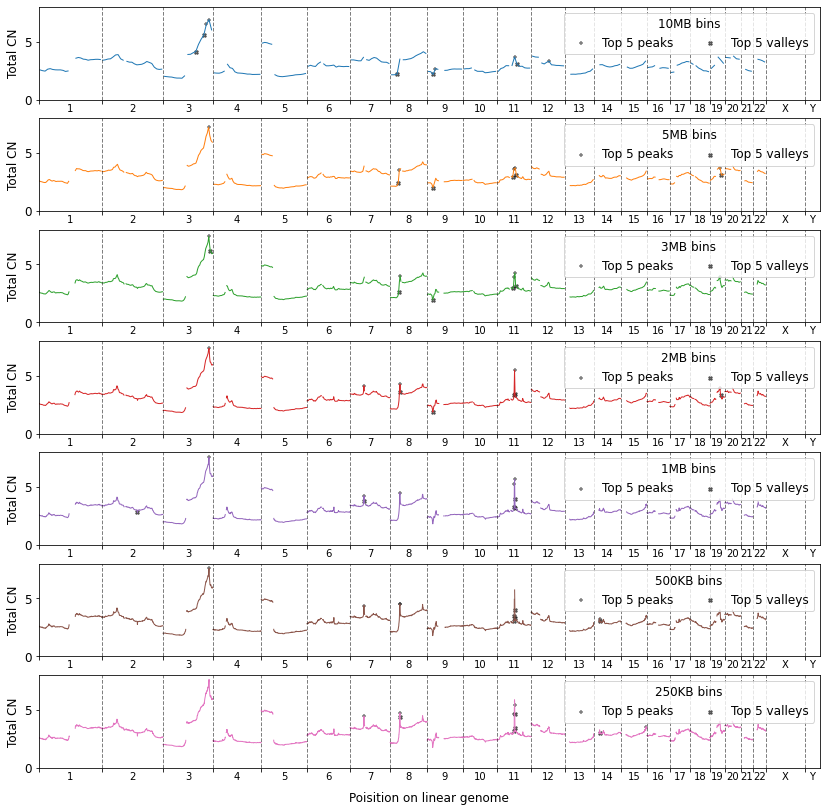

In [ ]:
fig, axs = plt.subplots(len(cns_dfs), 1, figsize=(14, 14))

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	sel_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	sel_df["sample_id"] = f"mean {cancer_type} CN"
	sel_df["score"] = cns.calc_angles(sel_df, "total_cn")

	cns.plot_lines(axs[i], sel_df, cn_column="total_cn", color=color_map[i])
	cns.plot_x_lines(axs[i])
	cns.plot_x_ticks(axs[i])

	sel_df = cns.add_cum_mid(sel_df)
	sel_df = sel_df.sort_values(by="score")
	axs[i].scatter(sel_df["cum_mid"].head(val_count), sel_df["total_cn"].head(val_count), color="k", alpha=0.5, s=15, label=f"Top {val_count} peaks", marker="+")
	axs[i].scatter(sel_df["cum_mid"].tail(val_count), sel_df["total_cn"].tail(val_count), color="k", alpha=0.5, s=15, label=f"Top {val_count} valleys", marker="X")
	axs[i].set_ylim(0, 8)
	axs[i].set_ylabel("Total CN")
	axs[i].legend(title=f"{grouping} bins", loc="upper right", ncol=3)

axs[-1].set_xlabel("Poisition on linear genome")

cdu.save_cns_fig("peaks_valleys_{cancer_type}")

In [52]:
score_means = []

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	print(grouping)
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	sel_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	sel_df["sample_id"] = f"mean {cancer_type} CN"
	sel_df["score"] = cns.calc_angles(sel_df, "total_cn")	
	score_means.append(cns.mean_value_per_seg(sel_df, ensembl, "score"))

mean_dfs = {}
mean_df = score_means[0].copy()
for vals in score_means[1:]:
	mean_df["score"] += vals["score"]
mean_df["score"] /= len(score_means)
mean_df["total_cn"] = cns.mean_value_per_seg(sel_df, ensembl, "total_cn")["total_cn"]
mean_df = pd.merge(mean_df, cosmic_df, how="left")

print(mean_df[~mean_df["gene"].isna()].sort_values(by="score", ascending=True).head(10))
cns.save_cns(mean_df, cdu.pjoin(cdu.out_path, f"gene_scores_{cancer_type}.tsv"))

10MB
5MB
3MB
2MB
1MB
500KB
250KB
       chrom      start        end             name     score  total_cn  \
3698   chr11   70049268   70053496  ENSG00000168040 -1.427664  5.679763   
3691   chr11   69455854   69469242  ENSG00000110092 -1.193919  5.861743   
18149   chr8   38268655   38326352  ENSG00000077782 -0.756986  4.711992   
14166   chr3  181429713  181432221  ENSG00000181449 -0.649780  7.500447   
17294   chr7   55086713   55324313  ENSG00000146648 -0.326905  4.433787   
14152   chr3  178865901  178957881  ENSG00000121879 -0.295182  6.923450   
18498   chr8  128747679  128753674  ENSG00000136997 -0.277115  4.476789   
18781   chr9   35073831   35080013  ENSG00000221829 -0.236994  2.902800   
10988   chr2   61108655   61158745  ENSG00000162924 -0.233901  4.186584   
10986   chr2   60678301   60780702  ENSG00000119866 -0.233549  4.191277   

         gene  
3698     FADD  
3691    CCND1  
18149   FGFR1  
14166    SOX2  
17294    EGFR  
14152  PIK3CA  
18498     MYC  
18781   FANCG